# Lung Cancer Detection Using Machine Learning


In [67]:

# BLOCK 1: IMPORT LIBRARIES


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [68]:

# BLOCK 2: LOAD DATASET

from google.colab import files

uploaded = files.upload()

df = pd.read_csv("/content/survey lung cancer (1).csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

Saving survey lung cancer (1).csv to survey lung cancer (1).csv
Dataset loaded successfully.
Shape: (309, 16)


In [69]:

# BLOCK 3: DATASET OVERVIEW


print("Number of records:", df.shape[0])
print("Number of columns:", df.shape[1])
print("Number of input features:", df.shape[1] - 1)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nFirst 5 Records:")
display(df.head())

Number of records: 309
Number of columns: 16
Number of input features: 15

Column Names:
['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE ', 'ALLERGY ', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER']

First 5 Records:


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,M,69,1,2,2,1,1,2,1,2,2,2,2,2,2,YES
1,M,74,2,1,1,1,2,2,2,1,1,1,2,2,2,YES
2,F,59,1,1,1,2,1,2,1,2,1,2,2,1,2,NO
3,M,63,2,2,2,1,1,1,1,1,2,1,1,2,2,NO
4,F,63,1,2,1,1,1,1,1,2,1,2,2,1,1,NO


In [70]:

# BLOCK 4: CLEAN COLUMN NAMES


df.columns = df.columns.str.strip()

print("Cleaned column names:")
print(df.columns.tolist())

Cleaned column names:
['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN', 'LUNG_CANCER']


In [71]:

# BLOCK 5: DATA QUALITY CHECK


print("Missing values:")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\nDuplicate rows:", df.duplicated().sum())


Missing values:
GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL CONSUMING        0
COUGHING                 0
SHORTNESS OF BREATH      0
SWALLOWING DIFFICULTY    0
CHEST PAIN               0
LUNG_CANCER              0
dtype: int64

Total missing values: 0

Duplicate rows: 33


LUNG_CANCER
YES    270
NO      39
Name: count, dtype: int64


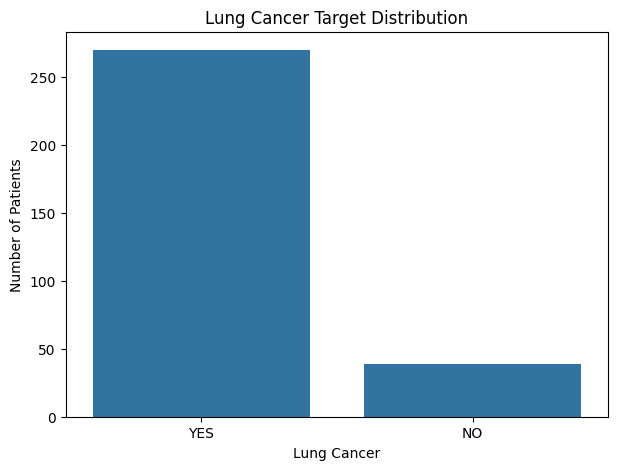

In [72]:

# BLOCK 6: TARGET VARIABLE DISTRIBUTION


print(df["LUNG_CANCER"].value_counts())

target_counts = df["LUNG_CANCER"].value_counts()

plt.figure(figsize=(7, 5))

sns.barplot(
    x=target_counts.index,
    y=target_counts.values
)

plt.title("Lung Cancer Target Distribution")
plt.xlabel("Lung Cancer")
plt.ylabel("Number of Patients")

plt.show()

In [73]:

# BLOCK 7: DATA ENCODING


# Encode target variable
df["LUNG_CANCER"] = df["LUNG_CANCER"].map({
    "YES": 1,
    "NO": 0
})

# Encode gender
df["GENDER"] = df["GENDER"].map({
    "M": 1,
    "F": 0
})

# Convert binary 1/2 features to 0/1
binary_features = [
    "SMOKING",
    "YELLOW_FINGERS",
    "ANXIETY",
    "PEER_PRESSURE",
    "CHRONIC DISEASE",
    "FATIGUE",
    "ALLERGY",
    "WHEEZING",
    "ALCOHOL CONSUMING",
    "COUGHING",
    "SHORTNESS OF BREATH",
    "SWALLOWING DIFFICULTY",
    "CHEST PAIN"
]

for col in binary_features:
    df[col] = df[col].map({
        1: 0,
        2: 1
    })

print("Encoding completed.")
display(df.head())

Encoding completed.


,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL CONSUMING,COUGHING,SHORTNESS OF BREATH,SWALLOWING DIFFICULTY,CHEST PAIN,LUNG_CANCER
0,1,69,0,1,1,0,0,1,0,1,1,1,1,1,1,1
1,1,74,1,0,0,0,1,1,1,0,0,0,1,1,1,1
2,0,59,0,0,0,1,0,1,0,1,0,1,1,0,1,0
3,1,63,1,1,1,0,0,0,0,0,1,0,0,1,1,0
4,0,63,0,1,0,0,0,0,0,1,0,1,1,0,0,0


In [74]:

# BLOCK 8: VERIFY ENCODED DATA


print("Data types after encoding:")
print(df.dtypes)

print("\nChecking for remaining missing values:")
print(df.isnull().sum().sum())

Data types after encoding:
GENDER                   int64
AGE                      int64
SMOKING                  int64
YELLOW_FINGERS           int64
ANXIETY                  int64
PEER_PRESSURE            int64
CHRONIC DISEASE          int64
FATIGUE                  int64
ALLERGY                  int64
WHEEZING                 int64
ALCOHOL CONSUMING        int64
COUGHING                 int64
SHORTNESS OF BREATH      int64
SWALLOWING DIFFICULTY    int64
CHEST PAIN               int64
LUNG_CANCER              int64
dtype: object

Checking for remaining missing values:
0


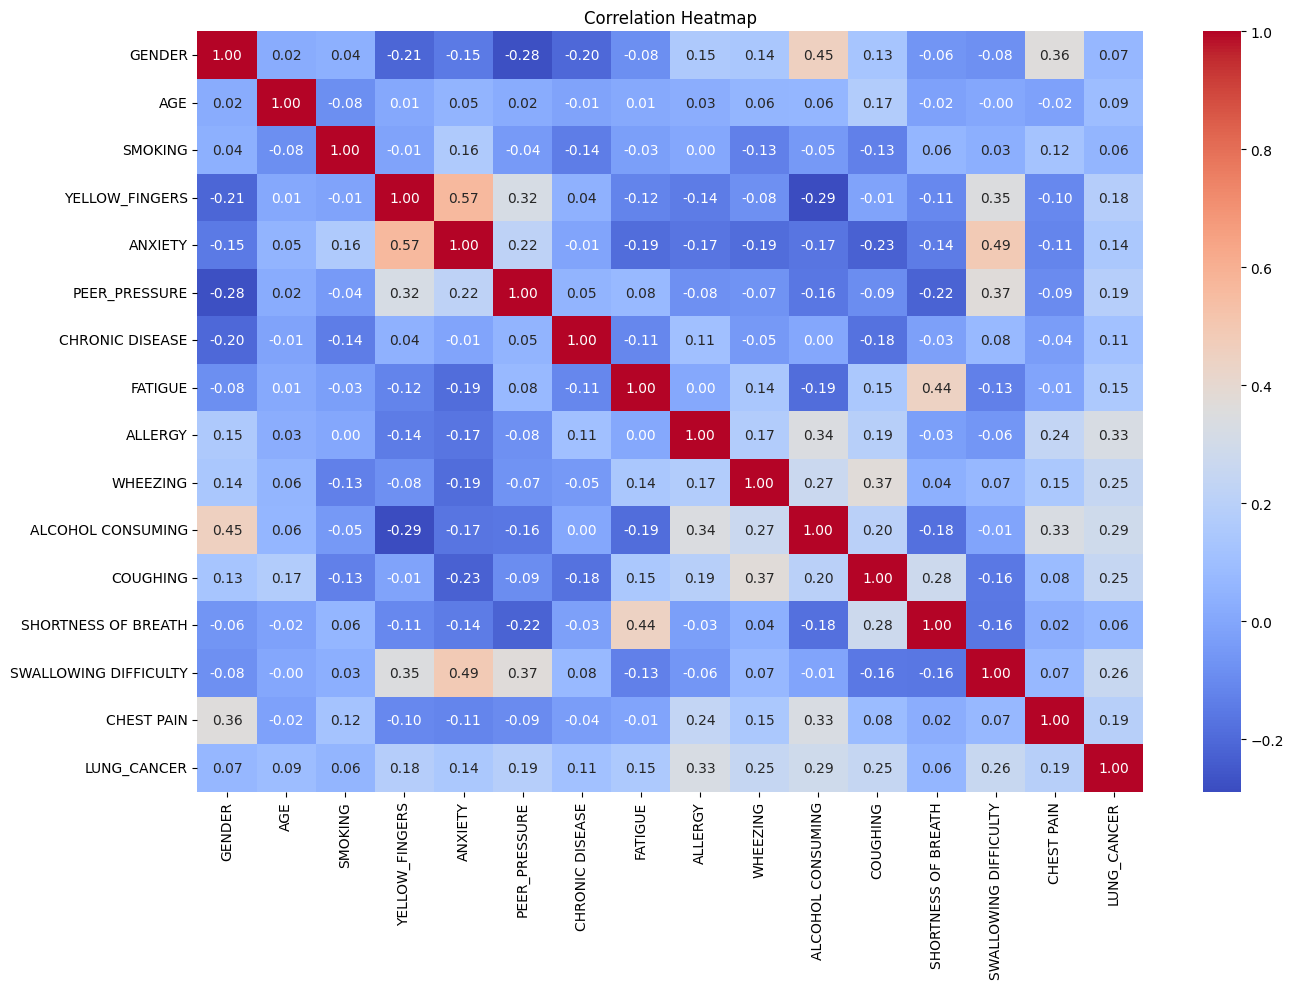

In [75]:

# BLOCK 9: CORRELATION HEATMAP


plt.figure(figsize=(14, 10))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [76]:

# BLOCK 10: SEPARATE FEATURES AND TARGET


X = df.drop("LUNG_CANCER", axis=1)
y = df["LUNG_CANCER"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeature names:")
print(X.columns.tolist())

Features shape: (309, 15)
Target shape: (309,)

Feature names:
['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY', 'PEER_PRESSURE', 'CHRONIC DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING', 'ALCOHOL CONSUMING', 'COUGHING', 'SHORTNESS OF BREATH', 'SWALLOWING DIFFICULTY', 'CHEST PAIN']


In [77]:

# BLOCK 11: TRAIN-TEST SPLIT


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))

Training records: 247
Testing records: 62


In [78]:

# BLOCK 12: MODEL TRAINING


# Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Decision Tree
dt = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)
dt.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf.fit(X_train, y_train)

print("All three models trained successfully.")

All three models trained successfully.


In [79]:

# BLOCK 13: MODEL PREDICTIONS


lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

print("Predictions generated successfully.")

Predictions generated successfully.


In [80]:

# BLOCK 14: ACCURACY COMPARISON


lr_acc = accuracy_score(y_test, lr_pred)
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print(f"Logistic Regression: {lr_acc * 100:.2f}%")
print(f"Decision Tree: {dt_acc * 100:.2f}%")
print(f"Random Forest: {rf_acc * 100:.2f}%")

Logistic Regression: 96.77%
Decision Tree: 95.16%
Random Forest: 96.77%


In [81]:

# BLOCK 15: COMPLETE MODEL EVALUATION


def evaluate_model(name, y_true, y_pred):

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)

    print(f"\n{name}")
    print("-" * 40)
    print(f"Accuracy : {accuracy * 100:.2f}%")
    print(f"Precision: {precision * 100:.2f}%")
    print(f"Recall   : {recall * 100:.2f}%")
    print(f"F1 Score : {f1 * 100:.2f}%")

    return accuracy, precision, recall, f1


lr_metrics = evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred
)

dt_metrics = evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

rf_metrics = evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)


Logistic Regression
----------------------------------------
Accuracy : 96.77%
Precision: 98.33%
Recall   : 98.33%
F1 Score : 98.33%

Decision Tree
----------------------------------------
Accuracy : 95.16%
Precision: 98.31%
Recall   : 96.67%
F1 Score : 97.48%

Random Forest
----------------------------------------
Accuracy : 96.77%
Precision: 98.33%
Recall   : 98.33%
F1 Score : 98.33%


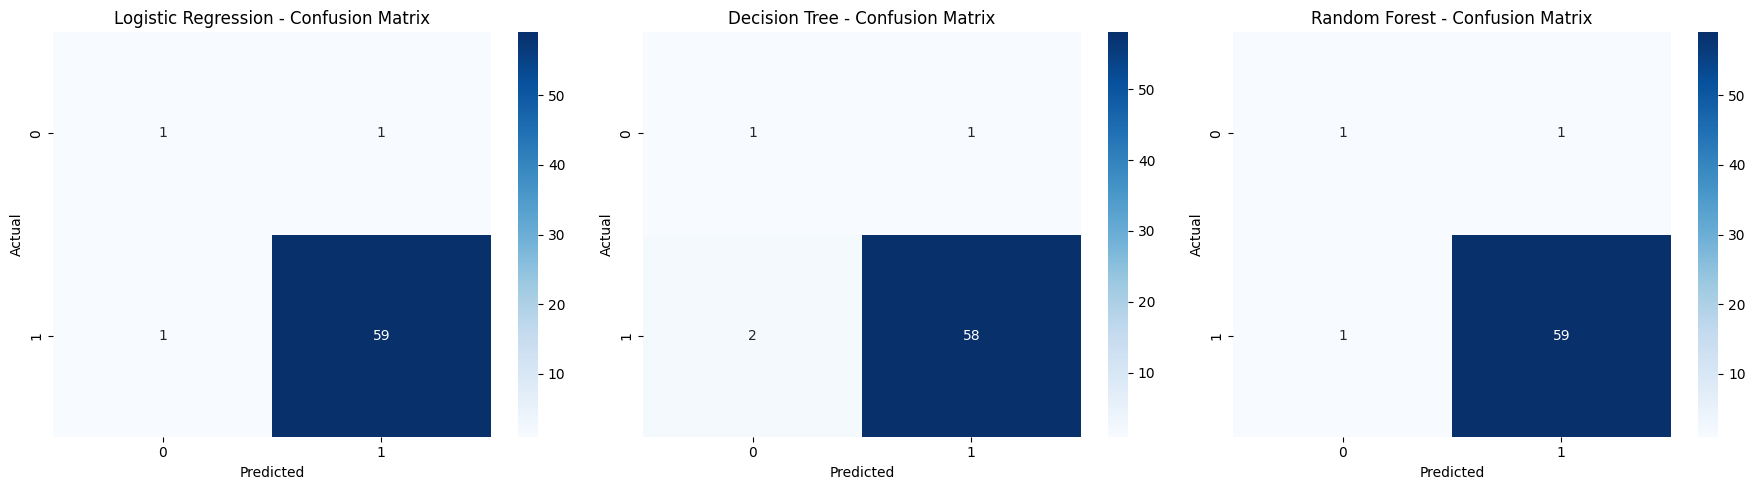

In [82]:

# BLOCK 16: CONFUSION MATRICES


fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_data = [
    ("Logistic Regression", lr_pred),
    ("Decision Tree", dt_pred),
    ("Random Forest", rf_pred)
]

for ax, (name, pred) in zip(axes, models_data):

    cm = confusion_matrix(y_test, pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax
    )

    ax.set_title(f"{name} - Confusion Matrix")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

In [83]:

# BLOCK 17: MODEL METRICS COMPARISON


results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        lr_metrics[0],
        dt_metrics[0],
        rf_metrics[0]
    ],

    "Precision": [
        lr_metrics[1],
        dt_metrics[1],
        rf_metrics[1]
    ],

    "Recall": [
        lr_metrics[2],
        dt_metrics[2],
        rf_metrics[2]
    ],

    "F1 Score": [
        lr_metrics[3],
        dt_metrics[3],
        rf_metrics[3]
    ]
})

display(results)

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.967742,0.983333,0.983333,0.983333
1,Decision Tree,0.951613,0.983051,0.966667,0.974790
2,Random Forest,0.967742,0.983333,0.983333,0.983333


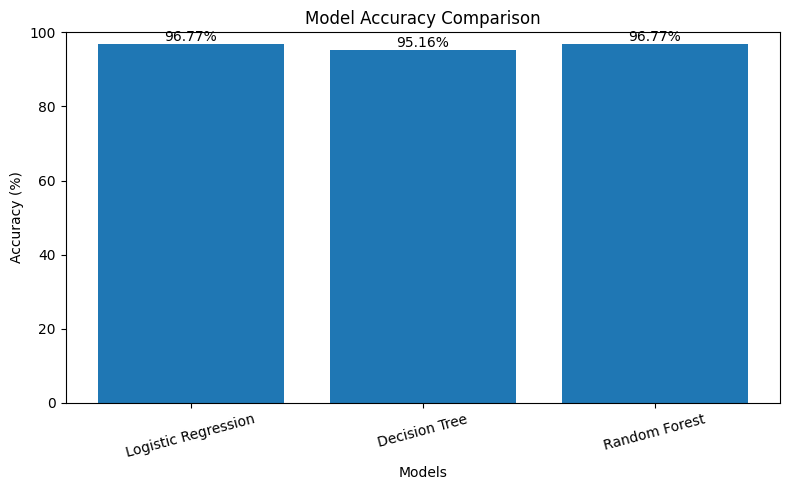

In [84]:

# BLOCK 18: ACCURACY COMPARISON GRAPH


plt.figure(figsize=(8, 5))

plt.bar(
    results["Model"],
    results["Accuracy"] * 100
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Models")
plt.title("Model Accuracy Comparison")

plt.ylim(0, 100)

for i, value in enumerate(results["Accuracy"] * 100):
    plt.text(
        i,
        value + 1,
        f"{value:.2f}%",
        ha="center"
    )

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

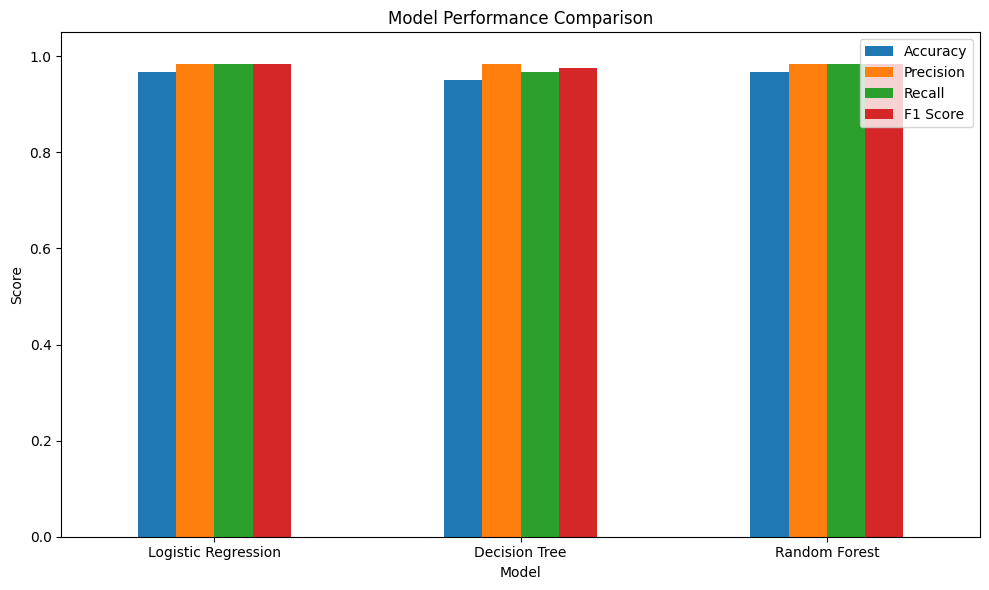

In [85]:

# BLOCK 19: ALL MODEL METRICS


metrics_to_plot = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]

results.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.ylabel("Score")
plt.xlabel("Model")
plt.title("Model Performance Comparison")

plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend()

plt.tight_layout()
plt.show()

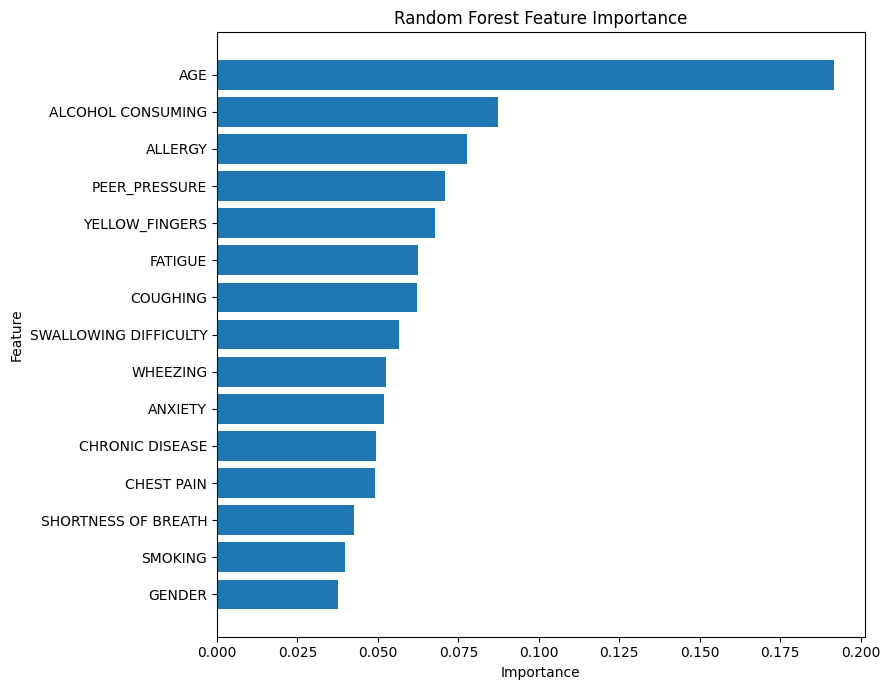

In [86]:

# BLOCK 20: RANDOM FOREST FEATURE IMPORTANCE


feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()

In [87]:

# BLOCK 21: FINAL MODEL SELECTION


print("FINAL MODEL SELECTION")
print("=" * 50)

print(f"Random Forest Accuracy: {rf_acc * 100:.2f}%")

print("\nRandom Forest was selected as the final model.")
print("Reason:")
print("- Achieved the highest tied accuracy.")
print("- Uses an ensemble of multiple decision trees.")
print("- Provides robust predictions.")
print("- Handles feature interactions effectively.")

FINAL MODEL SELECTION
Random Forest Accuracy: 96.77%

Random Forest was selected as the final model.
Reason:
- Achieved the highest tied accuracy.
- Uses an ensemble of multiple decision trees.
- Provides robust predictions.
- Handles feature interactions effectively.


In [88]:

# BLOCK 22: LUNG CANCER PREDICTION FUNCTION


def predict_lung_cancer(patient_data):

    prediction = rf.predict(patient_data)[0]

    if prediction == 1:
        return "Lung Cancer Detected"
    else:
        return "No Lung Cancer"

In [89]:

# BLOCK 24: CLASSIFICATION REPORTS


print("LOGISTIC REGRESSION")
print(classification_report(y_test, lr_pred))

print("\nDECISION TREE")
print(classification_report(y_test, dt_pred))

print("\nRANDOM FOREST")
print(classification_report(y_test, rf_pred))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.98      0.98      0.98        60

    accuracy                           0.97        62
   macro avg       0.74      0.74      0.74        62
weighted avg       0.97      0.97      0.97        62


DECISION TREE
              precision    recall  f1-score   support

           0       0.33      0.50      0.40         2
           1       0.98      0.97      0.97        60

    accuracy                           0.95        62
   macro avg       0.66      0.73      0.69        62
weighted avg       0.96      0.95      0.96        62


RANDOM FOREST
              precision    recall  f1-score   support

           0       0.50      0.50      0.50         2
           1       0.98      0.98      0.98        60

    accuracy                           0.97        62
   macro avg       0.74      0.74      0.74        62
weighted avg       0.97 

In [90]:

# BLOCK 25: FINAL PROJECT SUMMARY


print("LUNG CANCER DETECTION USING MACHINE LEARNING")
print("=" * 55)

print(f"Dataset Records : {len(df)}")
print(f"Input Features  : {X.shape[1]}")
print(f"Training Records: {len(X_train)}")
print(f"Testing Records : {len(X_test)}")

print("\nMODEL ACCURACY")
print(f"Logistic Regression: {lr_acc * 100:.2f}%")
print(f"Decision Tree      : {dt_acc * 100:.2f}%")
print(f"Random Forest      : {rf_acc * 100:.2f}%")

print("\nFINAL MODEL: RANDOM FOREST")

LUNG CANCER DETECTION USING MACHINE LEARNING
Dataset Records : 309
Input Features  : 15
Training Records: 247
Testing Records : 62

MODEL ACCURACY
Logistic Regression: 96.77%
Decision Tree      : 95.16%
Random Forest      : 96.77%

FINAL MODEL: RANDOM FOREST
